In [30]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
# set_theme: 테마 지정
path = os.path.join("..", "data", "18_열처리.csv")
df = pd.read_csv(path, encoding="utf-8")
sns.set_theme(style="whitegrid")

# 폰트 깨짐 방지
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

---
## **실습 1 - 첫 분포 그래프 그리기**
`histplot으로 한 센서의 분포를 그리고 축 제목 완성`

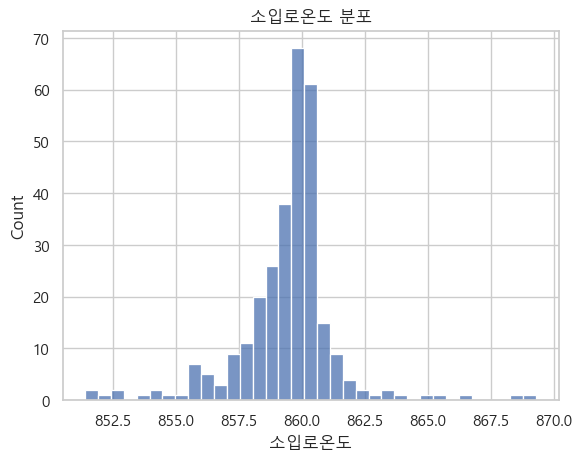

In [32]:
# data와 x에 볼 컬럼을 지정해 histplot 그리기
df_1 = pd.read_csv("..\\Data\\18_열처리.csv")

sns.histplot(data=df_1, x="소입로온도")
plt.title("소입로온도 분포")
plt.xlabel("소입로온도")
plt.show()

---
## **실습 2 - bins, KDE 조절**
> bins로 구간 수를, kde를 분포 곡선을 조절

In [33]:
# bins 값을 여러 개로 바꿔 가며 분포 그리기
df_2 = pd.read_csv("..\\Data\\18_열처리.csv")
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   라인      297 non-null    str    
 1   소입로온도   297 non-null    float64
 2   제어출력    297 non-null    float64
 3   건조출력    297 non-null    float64
 4   세정기     297 non-null    float64
 5   CP값     297 non-null    float64
 6   판정      297 non-null    str    
dtypes: float64(5), str(2)
memory usage: 16.4 KB


[16, 30, 10, 21, 19]


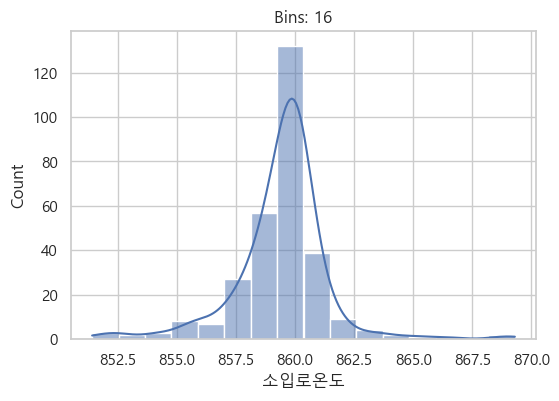

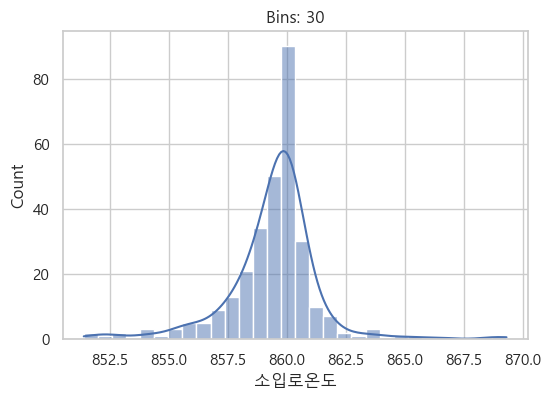

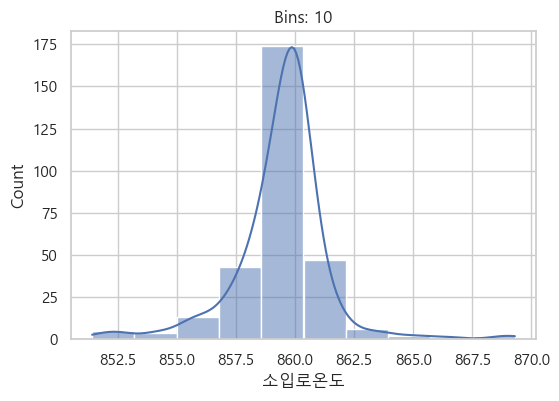

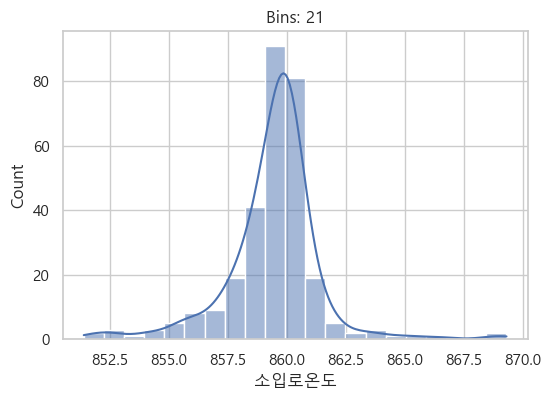

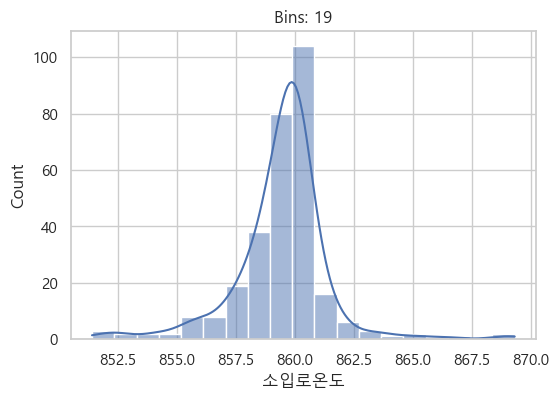

In [34]:
import random
bins_list = [random.randint(10,30) for _ in range(5)]
print(bins_list)
for b in bins_list:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df_2, x="소입로온도",
             bins=b, kde=True)
    plt.title(f"Bins: {b}")
    plt.show()

---
## **실습 3 - 양품 불량 분포 비교**
`hue로 판정별 분포를 색으로 겹쳐 비교`

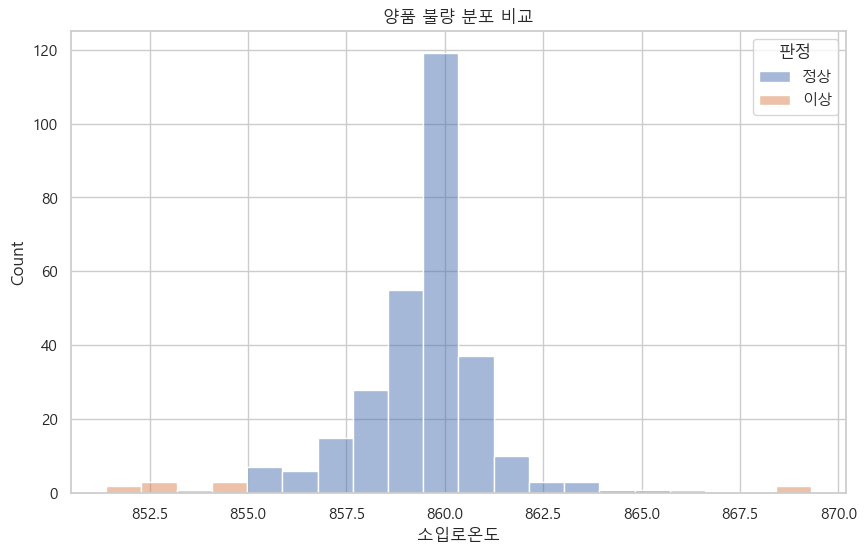

In [35]:
# x에 소입로온도, hue에 판정을 지정해 histplot 그리기
df_3 = pd.read_csv("..\\Data\\18_열처리.csv")
plt.figure(figsize=(10,6))
sns.histplot(data=df_3, x="소입로온도",
             hue="판정", bins=20)
plt.title("양품 불량 분포 비교")
plt.show()


## **실습 4 - 여러 센서 분포 한 눈에 보기**
`반복문으로 여러 센서의 분포를 차례로 그려 비교`

['라인', '소입로온도', '제어출력', '건조출력', '세정기', 'CP값', '판정']


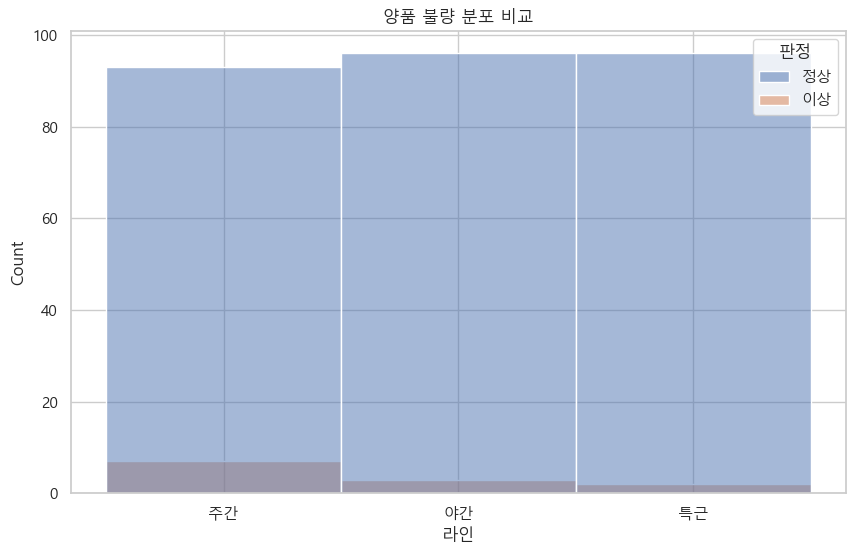

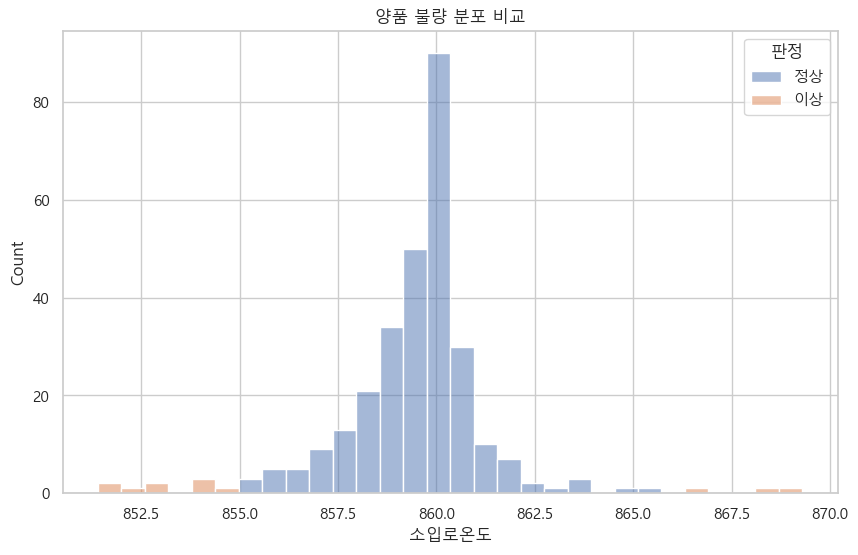

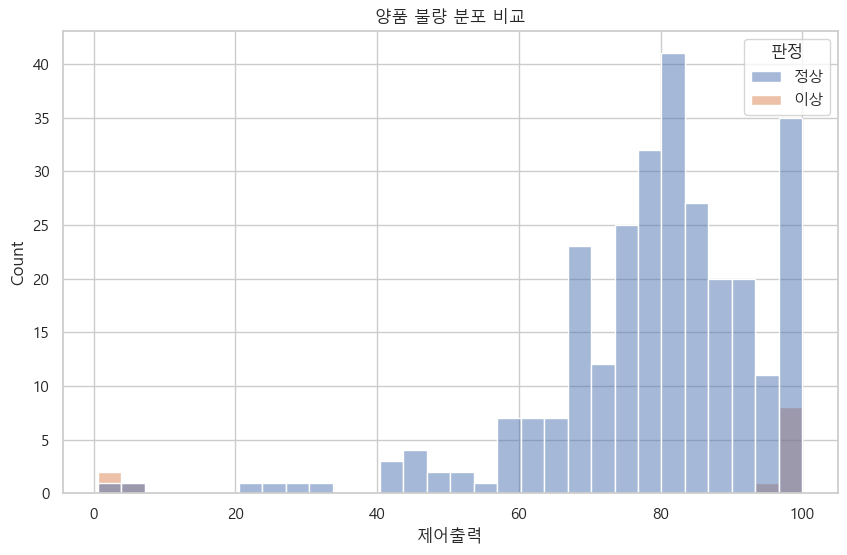

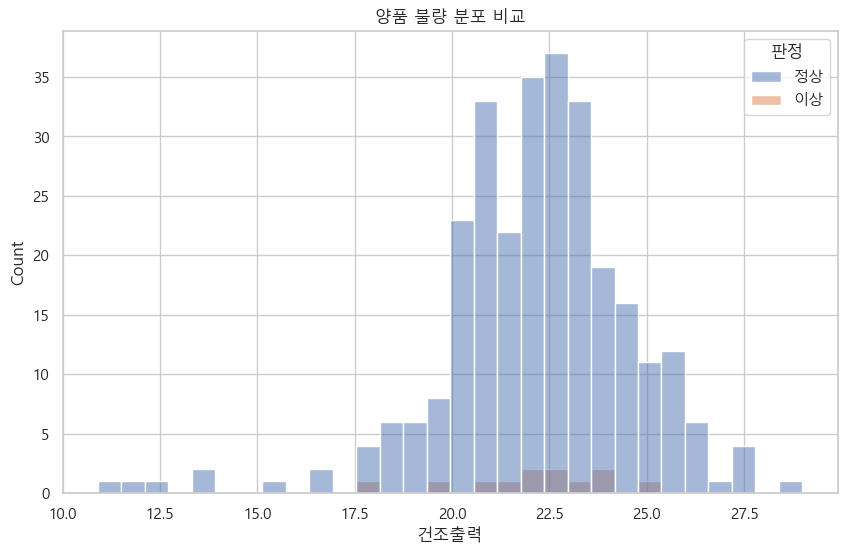

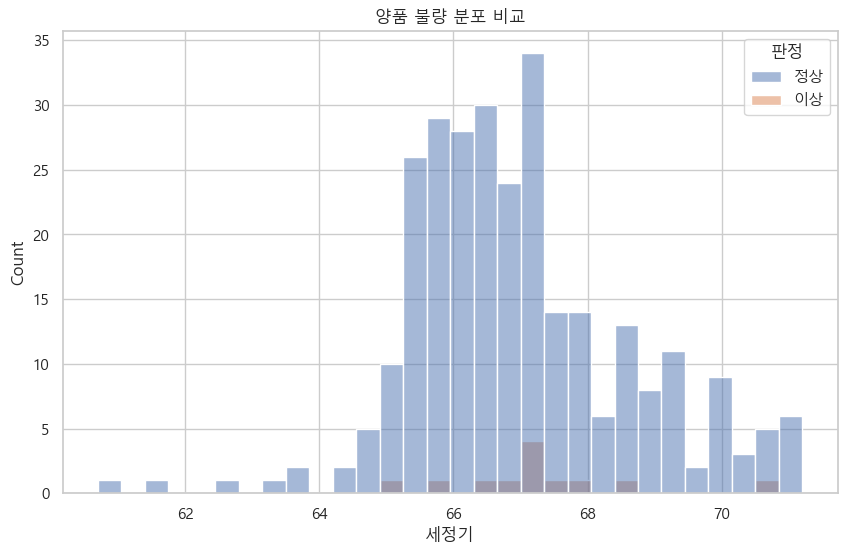

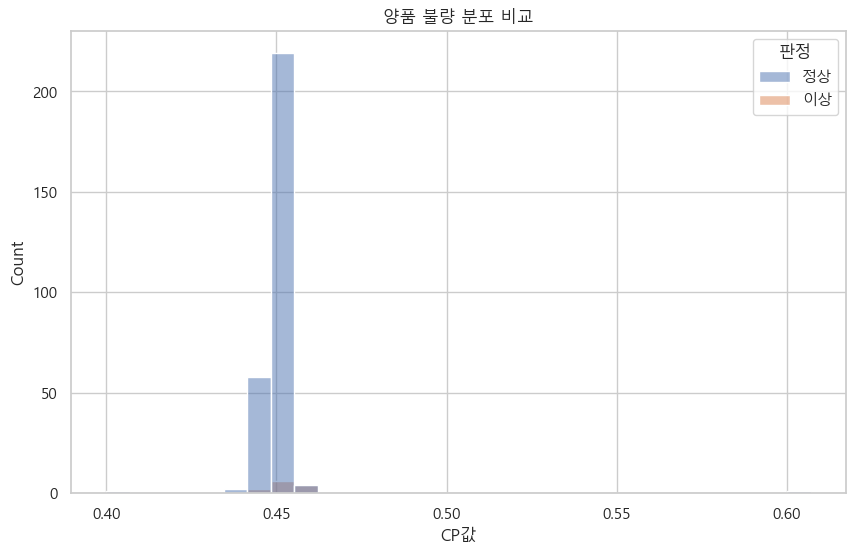

In [36]:
df_4 = pd.read_csv("..\\Data\\18_열처리.csv")

cols = list(df_4.columns)
print(cols)

# 컬럼과 단위 목록을 반복하며 각 센서 분포 그리기

for c in cols[0:-1]: 
    plt.figure(figsize=(10,6))
    sns.histplot(data=df_4, x=c,
                hue="판정", bins=30)
    plt.title("양품 불량 분포 비교")
    plt.show()

## **실습 5 - 단일 센서 박스플롯**
`boxplot으로 한 센서의 사분위수 / 이상치 확인`

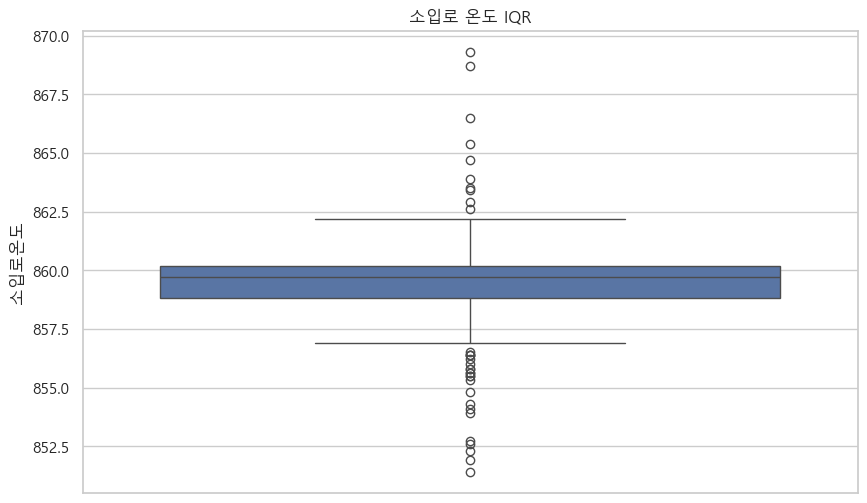

In [37]:
df_5 = pd.read_csv("..\\Data\\18_열처리.csv")

# y에 한 센서를 지정해 박스 플롯 그리기
# 상자와 수염, 이상치 점 확인
# 제목 / 축 이름 붙이기
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_5, y="소입로온도")
plt.title("소입로 온도 IQR")
plt.show()

## **실습 6 - 범주별 박스플롯 비교**
`라인별, 그리고 라인×판정 교차로 분포 비교`

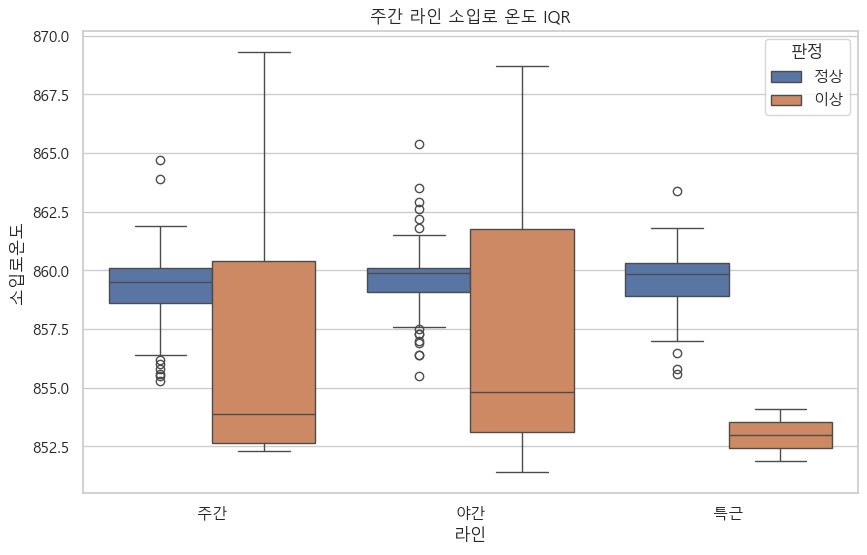

In [39]:
df_6 = pd.read_csv("..\\Data\\18_열처리.csv")

# x에 설비라인을 지정해 라인별 상자를 나란히 그리기
day = df_6[df_6["라인"] == "주간"] # 주간 라인 지정

# hue에 판정을 더해 라인마다 양품·불량 상자 비교
# 일관된 패턴이 신뢰할 신호임을 확인
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_6, x="라인", y="소입로온도", hue="판정")
plt.title("주간 라인 소입로 온도 IQR")
plt.show()

---
## **실습 7 - countplot / barplot**
`개수는 countplot, 평균은 barplot으로 범주 비교`

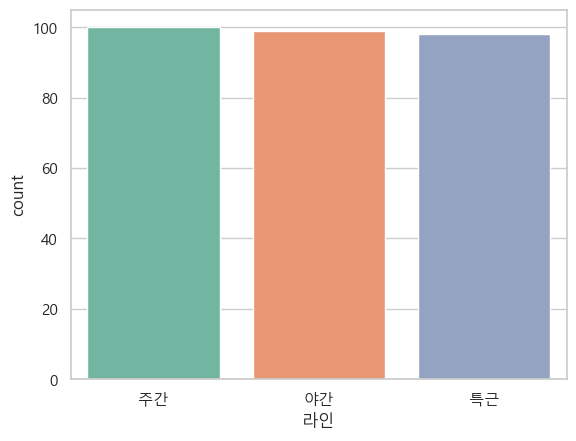

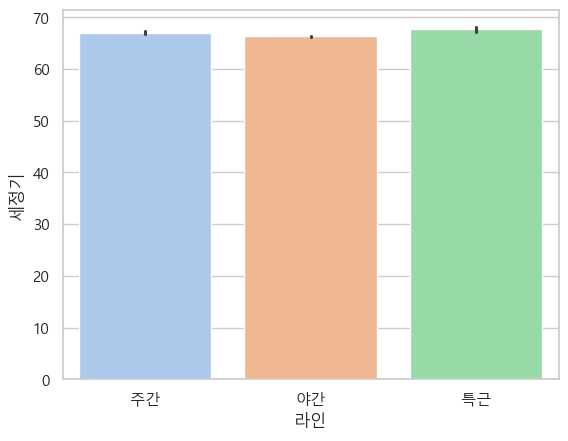

In [42]:
df_7 = pd.read_csv("..\\Data\\18_열처리.csv", encoding='utf-8')

# countplot으로 라인별 데이터 개수를 막대로 세기
sns.countplot(data=df_7, x="라인", hue="라인", palette="Set2", legend=False)
plt.show()
# barplot으로 라인별 평균 전류를 막대로 비교
sns.barplot(data=df_7, x="라인", y="세정기", hue="라인", palette='pastel', legend=False)
plt.show()
# 색은 hue와 palette로 지정(범례는 끄기)

---
## **실습 8 - 라인별 불량 비율 비교**
`라인별 양품, 불량 개수를 그래프와 표로 정리`

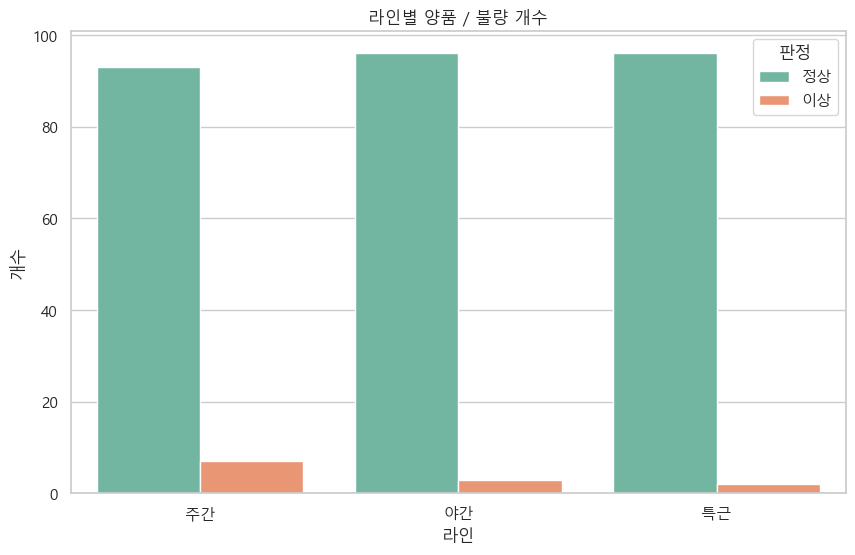

[라인 x 판정 개수]
판정  이상  정상
라인        
야간   3  96
주간   7  93
특근   2  96

[불량률까지 계산한 표]
판정  이상  정상   합계  불량률(%)
라인                     
주간   7  93  100     7.0
야간   3  96   99     3.0
특근   2  96   98     2.0


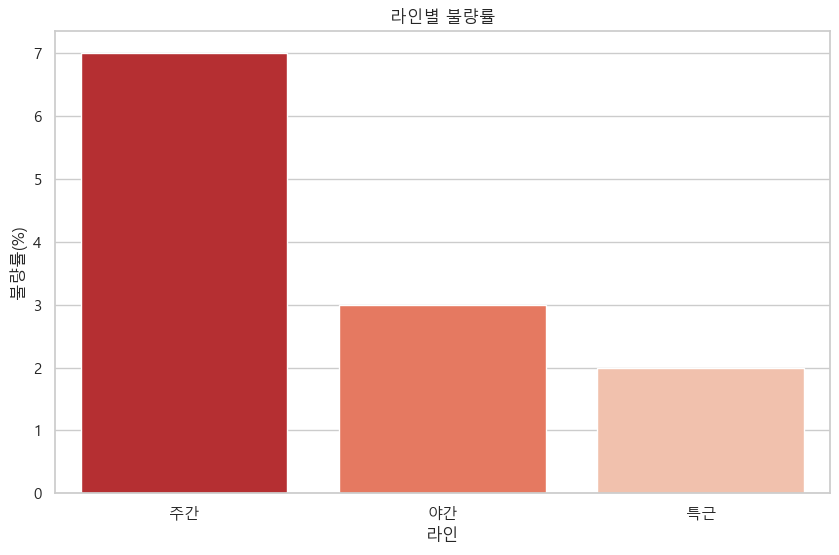

In [44]:
df_8 = pd.read_csv("..\\Data\\18_열처리.csv", encoding="utf-8")

# countplot에 hue로 판정을 넣어 라인별 양품·불량 개수 비교
plt.figure(figsize=(10, 6))
sns.countplot(data=df_8, x="라인", hue="판정", palette="Set2")
plt.title("라인별 양품 / 불량 개수")
plt.xlabel("라인")
plt.ylabel("개수")
plt.show()

# groupby와 unstack으로 라인x판정 개수 표 만들기
# groupby로 두 기준을 묶으면 세로로 길게 나오므로 unstack으로 가로 표를 만든다
표_개수 = df_8.groupby(["라인", "판정"]).size().unstack(fill_value=0)
print("[라인 x 판정 개수]")
print(표_개수)

# 불량이 상대적으로 많은 라인 확인
# 라인마다 총 개수가 달라서 개수만 보면 안 되고 비율까지 봐야 한다
표_개수["합계"] = 표_개수.sum(axis=1)
표_개수["불량률(%)"] = (표_개수["이상"] / 표_개수["합계"] * 100).round(1)
print()
print("[불량률까지 계산한 표]")
print(표_개수.sort_values("불량률(%)", ascending=False))

# 불량률을 막대로 한 번 더 확인
plt.figure(figsize=(10, 6))
비율 = 표_개수["불량률(%)"].sort_values(ascending=False)
sns.barplot(x=비율.index, y=비율.values, hue=비율.index, palette="Reds_r", legend=False)
plt.title("라인별 불량률")
plt.xlabel("라인")
plt.ylabel("불량률(%)")
plt.show()

# [해석]
# 주간 라인이 7건 / 7.0%로 불량이 가장 많고, 특근이 2건 / 2.0%로 가장 적다
# 라인별 총 개수가 100 / 99 / 98로 거의 같아서 개수 순서와 비율 순서가 같게 나왔다
# 만약 라인마다 생산량이 크게 달랐다면 개수만 보고 판단하면 안 된다